# Visual Similarity Search for Shoes (CLIP + ChromaDB)

This notebook builds a visual similarity search system using **CLIP** (Contrastive Language-Image Pretraining) and **ChromaDB** vector database.

**What this notebook does:**
1. Loads product images and metadata
2. Extracts 512-D visual embeddings using CLIP ViT-B/32
3. Stores embeddings + metadata in ChromaDB (persistent vector database)
4. Implements similarity search with optional filtering by subcategory/gender
5. Returns top-5 similar products with full information

**Prerequisites:**
- `raw_data/images_filtered/` folder with product images (created by `preprocess_data.ipynb`)
- `raw_data/articles_filtered.csv` with product metadata
- Required packages: `open-clip-torch`, `chromadb`, `torch`, `pandas`, `matplotlib`

## Step 1: Import Required Libraries

We use:
- `open_clip` for CLIP model (visual feature extraction)
- `torch` for tensor operations
- `chromadb` for vector database (stores embeddings + metadata, handles similarity search)
- `pandas` for product metadata
- `matplotlib` + `PIL` for displaying images

In [1]:
import numpy as np
import pandas as pd
import os
from pathlib import Path

# Image processing
from PIL import Image
import matplotlib.pyplot as plt

# Deep learning - CLIP
import open_clip
import torch

# Vector database
import chromadb

# Progress bar
from tqdm import tqdm

print(f"PyTorch version: {torch.__version__}")
print(f"ChromaDB version: {chromadb.__version__}")

PyTorch version: 2.10.0
ChromaDB version: 1.4.1


## Step 2: Configuration

Define all paths and parameters in one place.

In [2]:
# Paths
IMAGES_DIR = '../raw_data/images_filtered'
ARTICLES_CSV = '../raw_data/articles_filtered.csv'
CHROMA_DIR = '../embeddings/chroma'
COLLECTION_NAME = 'shoe_embeddings'

# Model parameters
IMAGE_SIZE = (224, 224)  # CLIP ViT-B/32 native input size
TOP_K = 5  # Number of similar items to return

# Create ChromaDB directory
os.makedirs(CHROMA_DIR, exist_ok=True)

print(f"Images directory: {IMAGES_DIR}")
print(f"ChromaDB directory: {CHROMA_DIR}")

Images directory: ../raw_data/images_filtered
ChromaDB directory: ../embeddings/chroma


## Step 3: Load Product Metadata

Load the articles CSV file containing product information.

In [3]:
# Load articles data
df_articles = pd.read_csv(ARTICLES_CSV)
print(f"Total articles in CSV: {len(df_articles)}")

info_columns = ['article_id', 'prod_name', 'product_type_name', 'colour_group_name',
                'department_name', 'index_group_name']
df_articles_info = df_articles[info_columns].copy()
df_articles_info.head()

Total articles in CSV: 5156


,article_id,prod_name,product_type_name,colour_group_name,department_name,index_group_name
0,181160009,Eva chelsea boot,Boots,Yellowish Brown,Divided Shoes,Divided
1,212042036,Mimmi sneaker,Sneakers,Other,Divided Shoes,Divided
2,212042070,Mimmi sneaker,Sneakers,White,Divided Shoes,Divided
3,258650001,Berlin boot,Boots,Black,Divided Shoes,Divided
4,264713001,Al Car Shoe,Other shoe,Dark Blue,Shoes / Boots inactive from s5,Menswear


## Step 4: Load Image File List

Get list of all available images from the subfolder structure.

In [4]:
# Get all image files from subfolder structure (created by preprocess_data.ipynb)
image_files = []
for subfolder in sorted(os.listdir(IMAGES_DIR)):
    subfolder_path = os.path.join(IMAGES_DIR, subfolder)
    if not os.path.isdir(subfolder_path):
        continue
    for f in sorted(os.listdir(subfolder_path)):
        if f.endswith('.jpg'):
            image_files.append(f)

print(f"Total images found: {len(image_files)}")


def filename_to_article_id(filename):
    """Convert filename like '0181160009.jpg' to article_id 181160009"""
    return int(filename.replace('.jpg', ''))


def get_image_path(filename):
    """Get full path for an image, using subfolder structure (018/0181160009.jpg)"""
    subfolder = filename[:3]
    return os.path.join(IMAGES_DIR, subfolder, filename)


print(f"\nSample:")
for i in range(3):
    print(f"  {image_files[i]} -> {get_image_path(image_files[i])}")

Total images found: 5156

Sample:
  0181160009.jpg -> ../raw_data/images_filtered/018/0181160009.jpg
  0212042036.jpg -> ../raw_data/images_filtered/021/0212042036.jpg
  0212042070.jpg -> ../raw_data/images_filtered/021/0212042070.jpg


## Step 5: Load CLIP Model

CLIP (Contrastive Language-Image Pretraining) by OpenAI produces 512-D embeddings.

**First run downloads ~350 MB** (cached in `~/.cache/huggingface/` for future use).

In [5]:
# Load CLIP ViT-B/32 model
model, _, preprocess = open_clip.create_model_and_transforms(
    'ViT-B-32', pretrained='openai'
)
model.eval()

print("CLIP ViT-B/32 loaded")
print(f"Embedding dimension: 512")

/Users/kyryloprymak/.pyenv/versions/3.10.6/envs/shoppingassistant-env/lib/python3.10/site-packages/open_clip/factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(


CLIP ViT-B/32 loaded
Embedding dimension: 512


## Step 6: Define Feature Extraction Function

Extract a normalized 512-D embedding from any image using CLIP.

In [6]:
def extract_embedding(image_path):
    """Extract a normalized 512-D CLIP embedding from an image."""
    image = preprocess(Image.open(image_path).convert('RGB')).unsqueeze(0)
    with torch.no_grad():
        embedding = model.encode_image(image)
    # Normalize to unit length (for cosine similarity)
    embedding = embedding / embedding.norm(dim=-1, keepdim=True)
    return embedding.squeeze().cpu().numpy().tolist()


# Test the function
test_image = get_image_path(image_files[0])
test_emb = extract_embedding(test_image)
print(f"Test image: {image_files[0]}")
print(f"Embedding length: {len(test_emb)}")
print(f"Sample values: {test_emb[:5]}")

Test image: 0181160009.jpg
Embedding length: 512
Sample values: [-0.051416996866464615, -0.019513415172696114, 0.033585961908102036, 0.041230566799640656, 0.006903796922415495]


## Step 7: Initialize ChromaDB and Build Collection

ChromaDB is a vector database that stores embeddings together with metadata. It handles:
- **Persistent storage** (no need for separate .npy/.pkl files)
- **Similarity search** (no manual cosine similarity code needed)
- **Metadata filtering** (search only within "Sneakers" or "Ladieswear" in one call)

If the collection already exists, this step loads it instantly.

In [7]:
# Initialize ChromaDB persistent client
client = chromadb.PersistentClient(path=CHROMA_DIR)
collection = client.get_or_create_collection(
    name=COLLECTION_NAME,
    metadata={"hnsw:space": "cosine"}
)
print(f"Collection '{COLLECTION_NAME}' has {collection.count()} items")

# Build article_id -> metadata lookup
article_lookup = {}
for _, row in df_articles.iterrows():
    article_lookup[row['article_id']] = {
        'prod_name': str(row.get('prod_name', '')),
        'product_type_name': str(row.get('product_type_name', '')),
        'colour_group_name': str(row.get('colour_group_name', '')),
        'index_group_name': str(row.get('index_group_name', '')),
    }
print(f"Metadata loaded for {len(article_lookup)} articles")

Collection 'shoe_embeddings' has 5156 items
Metadata loaded for 5156 articles


In [10]:
# Populate ChromaDB collection (skip if already done)
if collection.count() >= len(image_files):
    print(f"Collection already has {collection.count()} items. Skipping extraction.")
else:
    existing_ids = set(collection.get()['ids']) if collection.count() > 0 else set()
    to_process = [f for f in image_files if f not in existing_ids]
    print(f"Total images: {len(image_files)}, already in DB: {len(existing_ids)}, to process: {len(to_process)}")

    BATCH_SIZE = 64
    for i in tqdm(range(0, len(to_process), BATCH_SIZE), desc="Extracting & storing"):
        batch = to_process[i:i + BATCH_SIZE]
        ids, embeddings, metadatas = [], [], []

        for filename in batch:
            try:
                emb = extract_embedding(get_image_path(filename))
            except Exception as e:
                print(f"Error: {filename}: {e}")
                continue

            aid = filename_to_article_id(filename)
            meta = article_lookup.get(aid, {})
            meta['article_id'] = aid
            meta['filename'] = filename

            ids.append(filename)
            embeddings.append(emb)
            metadatas.append(meta)

        if ids:
            collection.add(ids=ids, embeddings=embeddings, metadatas=metadatas)

    print(f"\nDone. Collection has {collection.count()} items.")

Total images: 5156, already in DB: 0, to process: 5156


Extracting & storing: 100%|██████████| 81/81 [03:11<00:00,  2.37s/it]


Done. Collection has 5156 items.


## Step 8: Similarity Search with ChromaDB

One `collection.query()` call handles similarity search AND metadata filtering. No manual cosine similarity needed.

In [8]:
def find_similar_shoes(query_image_path, top_k=5, subcategory=None, gender=None):
    """
    Find similar shoes using CLIP + ChromaDB

    Args:
        query_image_path: Path to query image
        top_k: Number of results
        subcategory: Optional filter by product_type_name (e.g., 'Sneakers')
        gender: Optional filter by index_group_name (e.g., 'Ladieswear').


    Returns:
        List of dicts with article info and similarity score
    """
    query_emb = extract_embedding(query_image_path)

    # Build optional metadata filter
    where = None
    conditions = []
    if subcategory:
        conditions.append({"product_type_name": {"$eq": subcategory}})
    if gender:
        conditions.append({"index_group_name": {"$eq": gender}})
    if len(conditions) == 1:
        where = conditions[0]
    elif len(conditions) > 1:
        where = {"$and": conditions}

    # Query ChromaDB (similarity + filtering in one call)
    kwargs = {
        "query_embeddings": [query_emb],
        "n_results": top_k + 1,
        "include": ["metadatas", "distances"],
    }
    if where:
        kwargs["where"] = where

    results = collection.query(**kwargs)

    # Build output (ChromaDB cosine distance = 1 - cosine_similarity)
    output = []
    for i, doc_id in enumerate(results['ids'][0]):
        similarity = 1.0 - results['distances'][0][i]
        if similarity > 0.9999:
            continue
        meta = results['metadatas'][0][i]
        output.append({
            'filename': meta.get('filename', doc_id),
            'similarity': round(similarity, 4),
            'article_id': meta.get('article_id', 0),
            'prod_name': meta.get('prod_name', ''),
            'product_type_name': meta.get('product_type_name', ''),
            'colour_group_name': meta.get('colour_group_name', ''),
            'index_group_name': meta.get('index_group_name', ''),
        })
        if len(output) >= top_k:
            break

    return output

## Step 9: Display Function

Show query image and similar results in a grid with product information.

In [9]:
def display_results(query_image_path, results):
    """Display query image and similar results in a grid."""
    n_results = len(results)
    fig, axes = plt.subplots(1, n_results + 1, figsize=(4 * (n_results + 1), 5))

    # Display query image
    query_img = Image.open(query_image_path)
    axes[0].imshow(query_img)
    axes[0].set_title('QUERY IMAGE', fontsize=12, fontweight='bold', color='blue')
    axes[0].axis('off')

    # Display similar images
    for i, item in enumerate(results):
        img_path = get_image_path(item['filename'])
        img = Image.open(img_path)

        axes[i + 1].imshow(img)
        axes[i + 1].axis('off')
        axes[i + 1].set_title(f"#{i+1} - Similarity: {item['similarity']:.3f}", fontsize=10)
        axes[i + 1].set_xlabel(
            f"{item['prod_name']}\n{item['product_type_name']} | {item['colour_group_name']}\n{item['index_group_name']}",
            fontsize=9
        )

    plt.tight_layout()
    plt.show()

    # Print detailed info
    print("\n" + "="*80)
    print("DETAILED RESULTS")
    print("="*80)
    for i, item in enumerate(results):
        print(f"\n#{i+1} | Similarity: {item['similarity']:.4f}")
        print(f"   Article ID: {item['article_id']}")
        print(f"   Name: {item['prod_name']}")
        print(f"   Type: {item['product_type_name']}")
        print(f"   Color: {item['colour_group_name']}")
        print(f"   Category: {item['index_group_name']}")

## Step 10: Demo - Search with Random Image

Selected random image: 0593398002.jpg



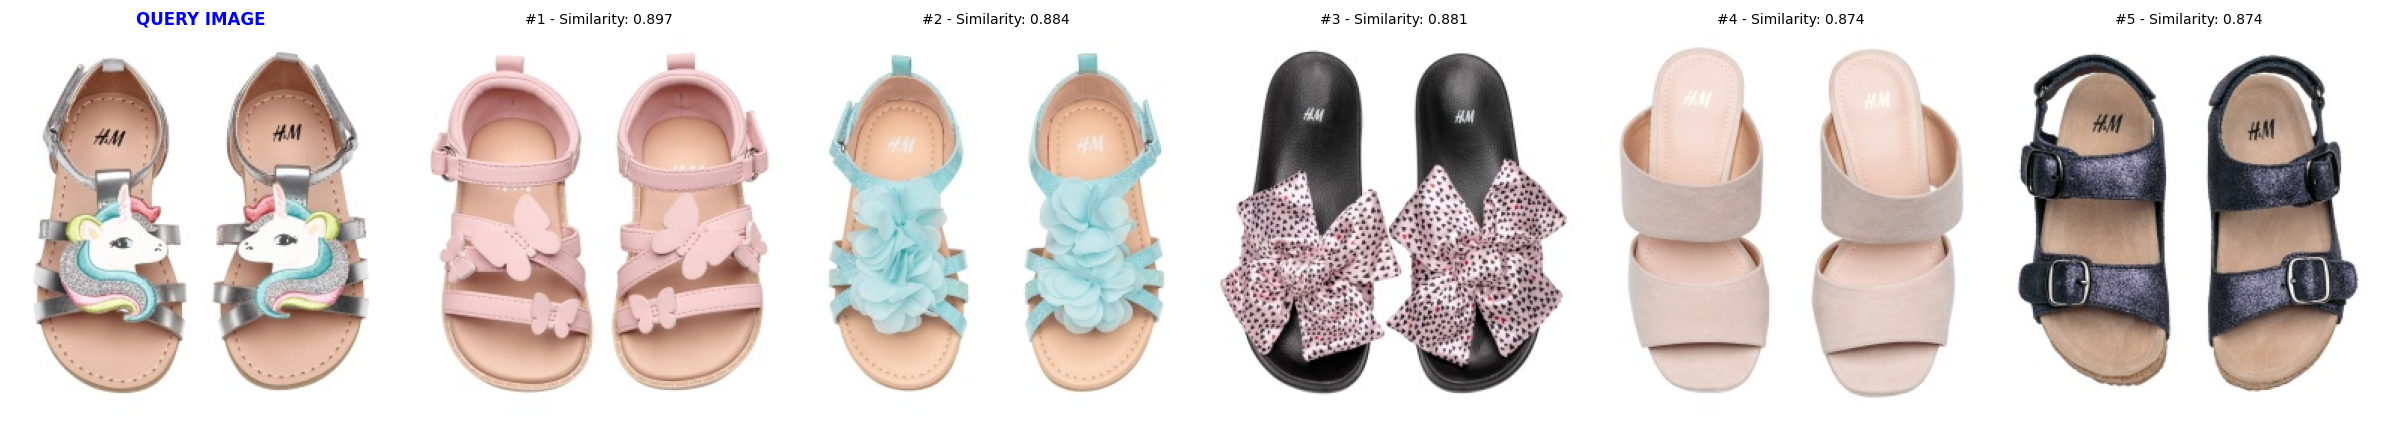


DETAILED RESULTS

#1 | Similarity: 0.8971
   Article ID: 616229003
   Name: Berry basic
   Type: Sandals
   Color: Light Pink
   Category: Baby/Children

#2 | Similarity: 0.8837
   Article ID: 593426002
   Name: CHLOE fluff sandal SG
   Type: Sandals
   Color: Light Turquoise
   Category: Baby/Children

#3 | Similarity: 0.8811
   Article ID: 614353001
   Name: Vail Slipper new
   Type: Slippers
   Color: Light Pink
   Category: Ladieswear

#4 | Similarity: 0.8742
   Article ID: 573665003
   Name: Rider mule
   Type: Heeled sandals
   Color: Light Beige
   Category: Ladieswear

#5 | Similarity: 0.8737
   Article ID: 558706002
   Name: Oline leather sandal SG
   Type: Sandals
   Color: Dark Blue
   Category: Baby/Children


In [10]:
# Select a random image from dataset
np.random.seed(42)
random_idx = np.random.randint(0, len(image_files))
random_image = image_files[random_idx]
query_path = get_image_path(random_image)

print(f"Selected random image: {random_image}\n")

results = find_similar_shoes(query_path, top_k=TOP_K)
display_results(query_path, results)

## Step 11: Demo - Filtered Search (by subcategory)

Filtered search: Sneakers only



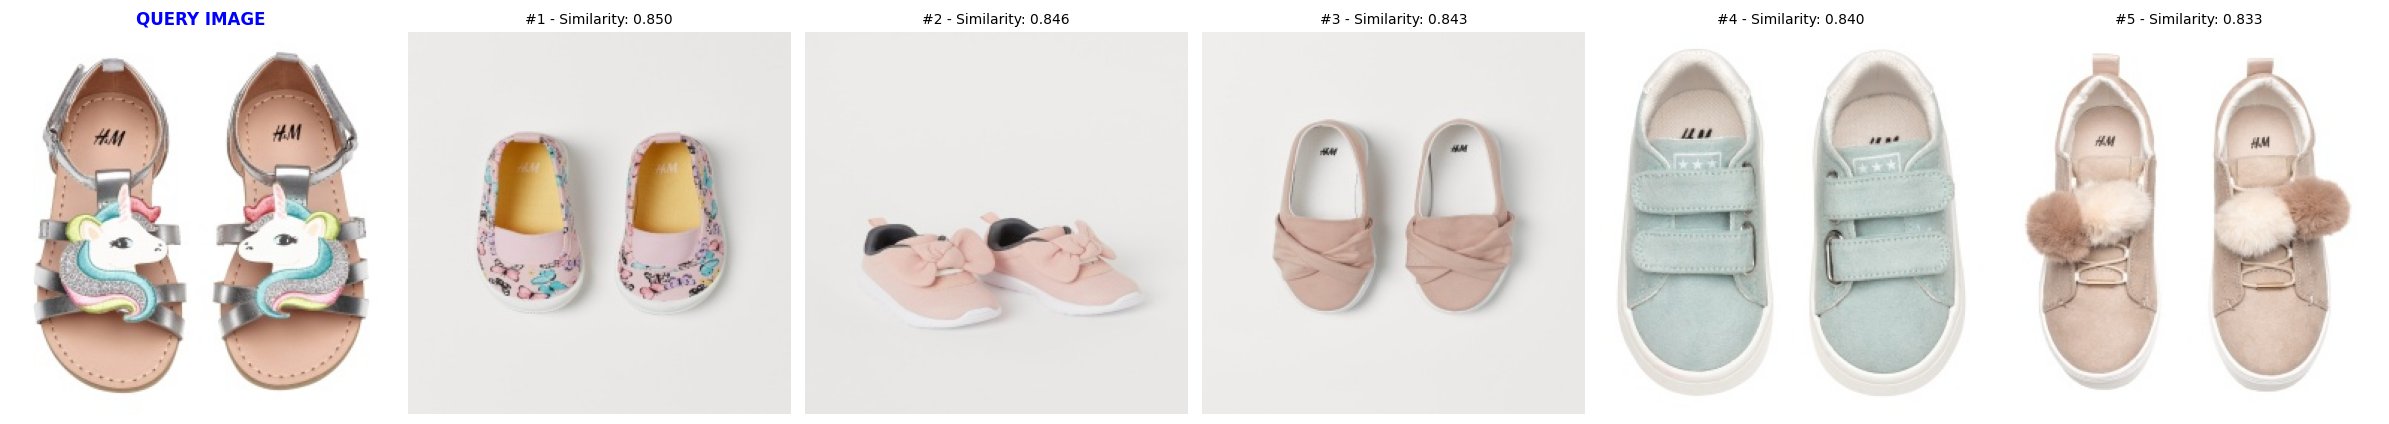


DETAILED RESULTS

#1 | Similarity: 0.8501
   Article ID: 690690003
   Name: Venice LOW SG
   Type: Sneakers
   Color: Light Pink
   Category: Baby/Children

#2 | Similarity: 0.8460
   Article ID: 804600001
   Name: Tessla sneaker
   Type: Sneakers
   Color: Light Pink
   Category: Baby/Children

#3 | Similarity: 0.8432
   Article ID: 698470005
   Name: Elena sneaker
   Type: Sneakers
   Color: Beige
   Category: Ladieswear

#4 | Similarity: 0.8395
   Article ID: 550589003
   Name: Johan sneaker
   Type: Sneakers
   Color: Light Turquoise
   Category: Baby/Children

#5 | Similarity: 0.8334
   Article ID: 608347003
   Name: Dolores fancy sneaker
   Type: Sneakers
   Color: Beige
   Category: Ladieswear


In [11]:
# Search only within Sneakers
results_sneakers = find_similar_shoes(query_path, top_k=TOP_K, subcategory='Sneakers')
print("Filtered search: Sneakers only\n")
display_results(query_path, results_sneakers)

## Step 12: Demo - Search with Another Random Image

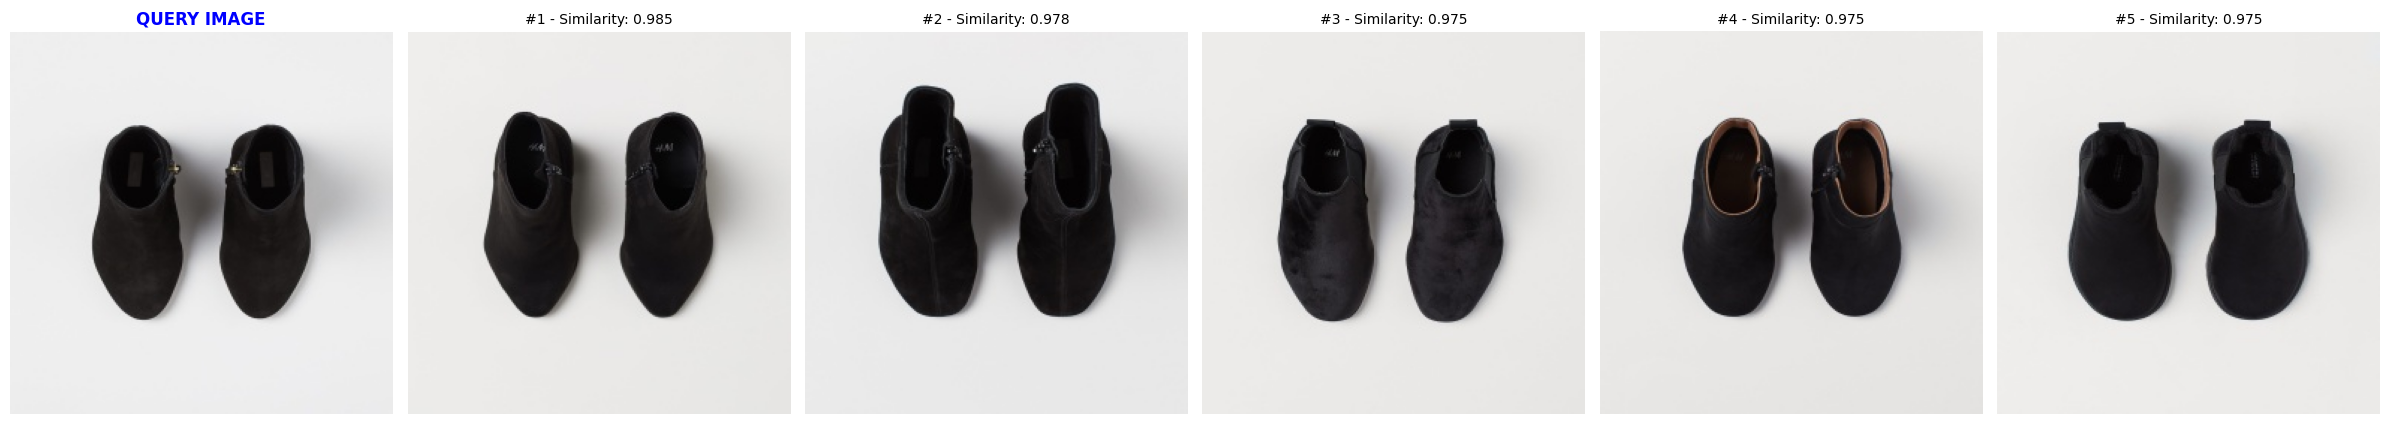


DETAILED RESULTS

#1 | Similarity: 0.9848
   Article ID: 672224001
   Name: Rubena
   Type: Boots
   Color: Black
   Category: Ladieswear

#2 | Similarity: 0.9783
   Article ID: 705860001
   Name: OL GRANITE PQ boot
   Type: Boots
   Color: Black
   Category: Ladieswear

#3 | Similarity: 0.9754
   Article ID: 647338011
   Name: Kobe Chelsea Boot
   Type: Boots
   Color: Black
   Category: Menswear

#4 | Similarity: 0.9754
   Article ID: 711982002
   Name: Bess
   Type: Boots
   Color: Black
   Category: Ladieswear

#5 | Similarity: 0.9752
   Article ID: 777441001
   Name: Carolina chelsea pile boot
   Type: Boots
   Color: Black
   Category: Ladieswear


In [12]:
# Another random image
random_idx = np.random.randint(0, len(image_files))
random_image = image_files[random_idx]
query_path = get_image_path(random_image)

results = find_similar_shoes(query_path, top_k=TOP_K)
display_results(query_path, results)

## Step 13: Search with Your Own Image

**To use your own image:**
1. Place your image in `raw_data/test_images/` folder
2. Update `custom_image_path` below
3. Run the cell

**Image requirements:** Any JPG/PNG, any resolution (resized automatically). Best results with a single shoe on a plain background.

Found image: ../raw_data/test_images/test_shoe.jpg



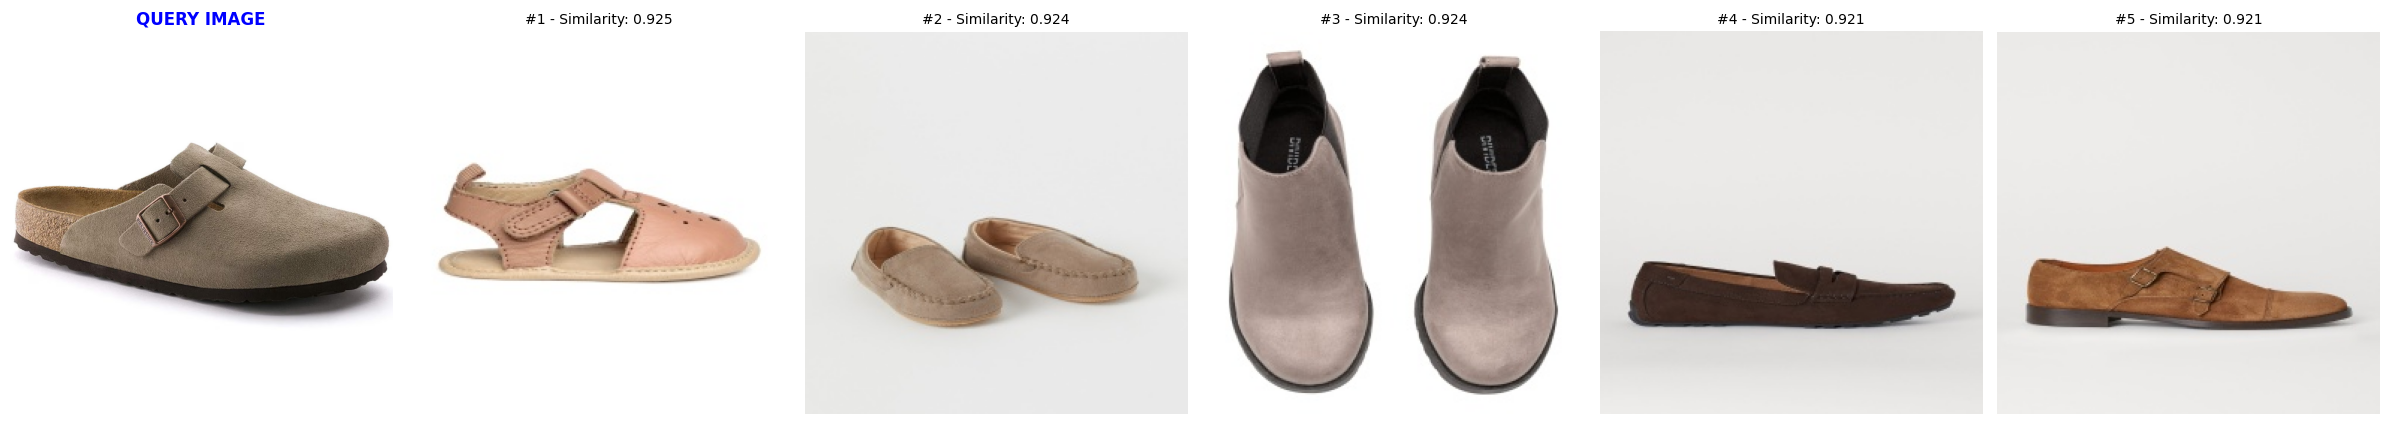


DETAILED RESULTS

#1 | Similarity: 0.9247
   Article ID: 525621001
   Name: BLUE sandal softsole
   Type: Sandals
   Color: Dark Beige
   Category: Baby/Children

#2 | Similarity: 0.9243
   Article ID: 852384001
   Name: Mr Louis
   Type: Other shoe
   Color: Beige
   Category: Baby/Children

#3 | Similarity: 0.9239
   Article ID: 502621002
   Name: Jenny Elastic
   Type: Boots
   Color: Greyish Beige
   Category: Divided

#4 | Similarity: 0.9215
   Article ID: 695341002
   Name: Preston carshoe
   Type: Other shoe
   Color: Yellowish Brown
   Category: Menswear

#5 | Similarity: 0.9212
   Article ID: 663350002
   Name: Omar monkstrap PQ
   Type: Other shoe
   Color: Yellowish Brown
   Category: Menswear


In [16]:
# Path to test image
custom_image_path = '../raw_data/test_images/test_shoe.jpg'

if os.path.exists(custom_image_path):
    print(f"Found image: {custom_image_path}\n")
    results = find_similar_shoes(custom_image_path, top_k=TOP_K)
    display_results(custom_image_path, results)
else:
    print(f"Image not found: {custom_image_path}")
    print("\nTo test with your own image:")
    print("1. Place your image in raw_data/test_images/")
    print("2. Update 'custom_image_path' above with the correct filename")

## Summary

This notebook implements a visual similarity search system for shoes using **CLIP + ChromaDB**:

**What we built:**
- Feature extraction using CLIP ViT-B/32 (512-D embeddings)
- ChromaDB vector database for persistent storage + similarity search
- Metadata filtering (search within specific subcategory or gender)

**Data stored in ChromaDB:**
- `embeddings/chroma/` directory (auto-managed by ChromaDB)
- Each entry contains: embedding (512-D), article_id, prod_name, product_type_name, colour_group_name, index_group_name